In [2]:
%pip install lightkurve matplotlib numpy --quiet



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
from lightkurve import search_targetpixelfile

%matplotlib inline

pixelfile = search_targetpixelfile("KIC 8462852", quarter=16).download(quality_bitmask='hardest');


/Users/wayfinder/Code/fault-in-our-stars/.env/lib/python3.13/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


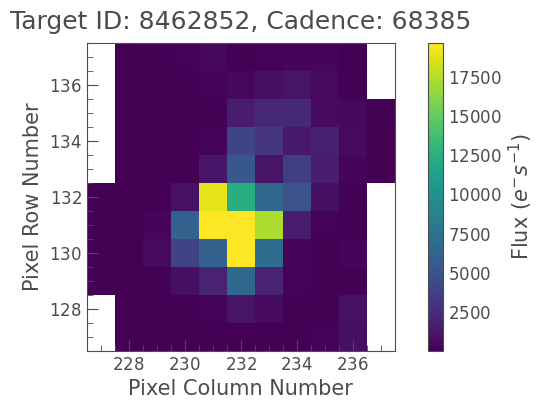

In [4]:
pixelfile.plot(frame=1000);


In [5]:
lc = pixelfile.to_lightcurve(aperture_mask='all');


In [6]:
lc.time, lc.flux


(<Time object: scale='tdb' format='bkjd' value=[1472.11777934 1472.13821223 1472.15864492 ... 1557.89718798 1557.9380561
  1557.95849016]>,
 <Quantity [258645.03, 258660.05, 258690.08, ..., 258929.86, 258884.66,
            258865.6 ] electron / s>)

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

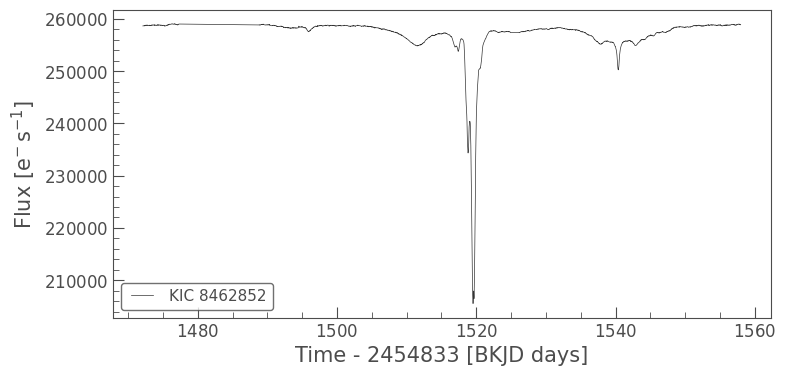

In [7]:
lc.plot()


In [8]:
pixelFile = search_targetpixelfile('KIC 6922244', quarter=4).download()


/Users/wayfinder/Code/fault-in-our-stars/.env/lib/python3.13/site-packages/lightkurve/search.py:420: LightkurveWarning: Warning: 4 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


In [9]:
lc = pixelFile.to_lightcurve(aperture_mask=pixelFile.pipeline_mask)


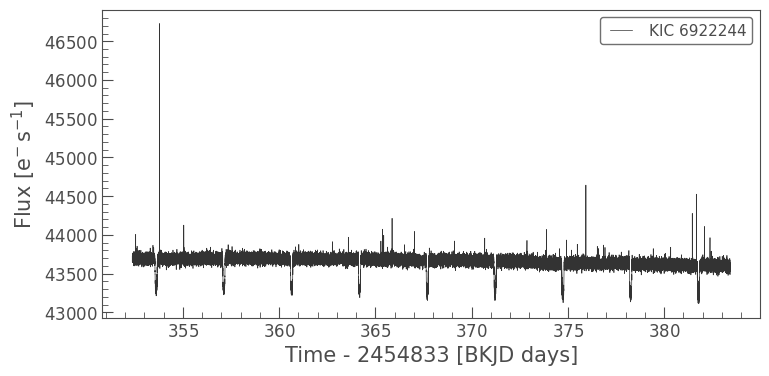

In [10]:
lc.plot();


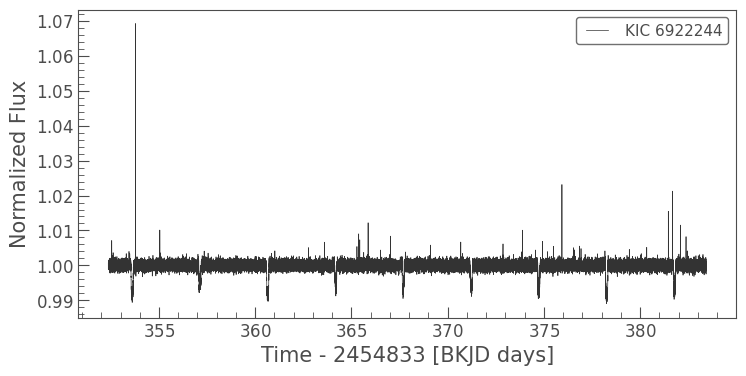

In [11]:
flat_lc = lc.flatten(window_length=401)
flat_lc.plot();


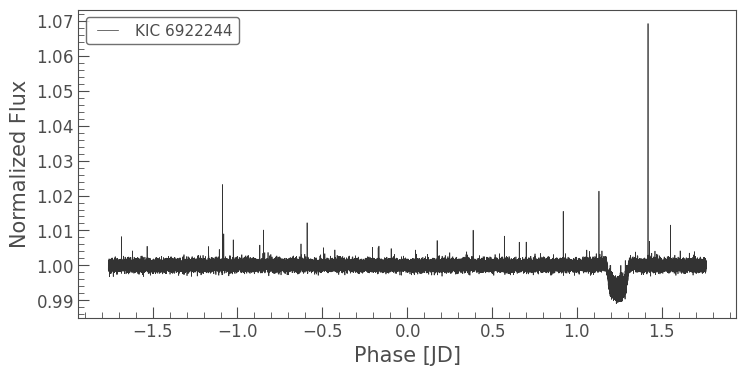

In [12]:
folded_lc = flat_lc.fold(period=3.522)
folded_lc.plot();


<Axes: title={'center': 'KIC 6922244'}, xlabel='Phase', ylabel='Cycle'>

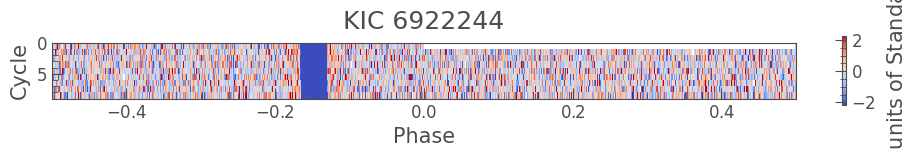

In [14]:
folded_lc.plot_river(bin_points=5, method='sigma')


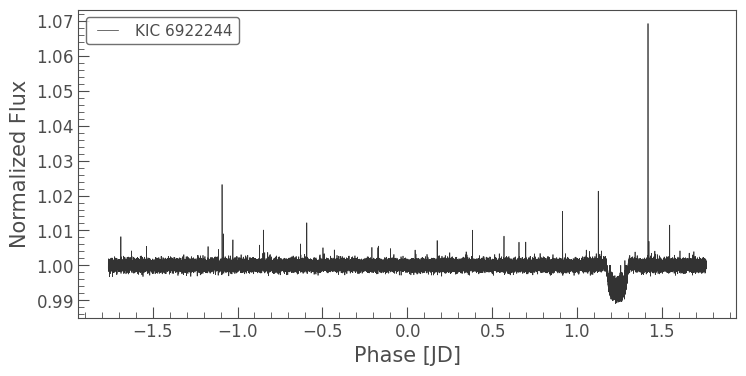

In [16]:
lc.remove_nans().flatten(window_length=401).fold(period=3.5225).plot();
